In [105]:
import numpy as np
import matplotlib.pyplot as plt
from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import jax.numpy as jnp
from jax import jit, vmap, grad

from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from jax import random
import jax
import time
import functions as f

In [106]:
device_name = "cpu"

We aim at minimizing $$\mathcal{F}_P(Q) = \mathcal{L}(Q) + D_{KL}(Q||Q_0)$$ where $Q_0 = \mathcal{N}(0,I_d)$ and $P$ is the minimizer and has a positive density $$p(x) \propto q_0(x) \exp(-\mathcal{L}'(P)(x)).$$
To do this we run the stochastic process, for $k=1,...,T$,
$$X[k+1] = X[k] - \eta \nabla 
V(X[k]) + \sqrt{2 \eta} Z[k]$$
where 
- X[k] is a set of particules at recursion $k$ ($n$ particules in $\mathbb{R}^d$) (shape $(n,d)$)
- $n$ is the number of particules and $d$ the dimension
- $Z[1],...,Z[T]$ are iid gaussian noises (shape $(n,d)$)
- $\nabla V (X[k]) = \nabla_W \mathcal{L}(\hat{Q}[k])(X[k]) - \nabla \log q_0(X[k])$ where $\hat{Q}[k] = \frac1n \sum_{j=1}^n \delta_{X^j[k]}$.



# I/ IMQ Kernel  : $k(x,y) = \frac{1}{\sqrt{c + \|x-y\|^2}}$.

# 1. $\mathcal{L}$ is linear.

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [107]:
c = jnp.array(1.0)
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    d = x.shape[0]
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 * jnp.pi)**d)
def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 
def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)

MFLD = MeanFieldLangevinDynamics(q_0,L,k)

In the following cell, for a number of iteration $T=500$, a number of $n$ particules in $\mathbb{R}^2$ we plot KGD and $\mathcal{F}_P$ evaluated on the last distribution of MFLD against the stepsize parameter $\eta$.

In [ ]:
T = 500
n = 50
d = 2
n_sim = 1

Eta = jnp.array([0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 3.0, 5.0])
device = jax.devices(device_name)[0]  

all_particles_fin = jax.device_put(jnp.zeros((len(Eta), n, d)), device)

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(100 + sim)
        key = random.PRNGKey(200 + sim)
        shape = (n, d)
        X0 = random.normal(key, shape) + 5 * jnp.ones((n, d))
        X0 = jax.device_put(X0, device)
        all_particles = MFLD.run_particles(eta, T, X0,key)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])


In [110]:
KGD_fin

Array([2.604625  , 1.9872339 , 0.67692757, 0.26188394, 0.24035676,
       0.22409111, 0.26973557, 0.2663385 , 0.3365935 , 0.38627127,
              nan], dtype=float32)

In [111]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X))

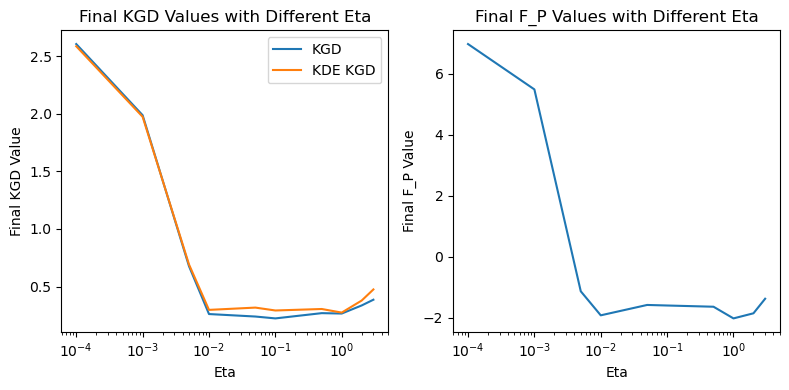

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin,label ='KGD')
axes[0].plot(Eta, KDE_KGD_fin,label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')   
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

plt.tight_layout()
plt.show()


# 2. Linear + Quadratic term 

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x) + \int \int w(x,x') \ d Q(x) d Q(x)$, with $v(x) = 1/2 \|x\|^2$ and $w(x,x') = x^Tx'$.

<!-- if w= 0
F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->

In [7]:
c = jnp.array(1.0)
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) / jnp.sqrt((2  *jnp.pi)**d)
def v(x):
    return -1/4 * jnp.linalg.norm(x,axis = 1)**2
def w(X):
    _X = jax.lax.stop_gradient(X).T
    return jnp.dot(X,_X)
def L(X):
     return np.mean(v(X)) + np.mean(w(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)

MFLD = MeanFieldLangevinDynamics(q_0,L,k)

In [8]:
T = 500
n = 100 
d = 2
Eta = jnp.array([0.001,0.005,0.01,0.05,0.1,0.2,0.5,1.0,2.0,5.0,10.0])
device = jax.devices(device_name)[0]  
n_sim = 1

all_particles_fin = jax.device_put(jnp.zeros((len(Eta), n, d)), device)

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(100 + sim)
        key = random.PRNGKey(200 + sim)
        shape = (n, d)
        X0 = random.normal(key_init, shape) + 5 * jnp.ones((n, d))
        X0 = jax.device_put(X0, device)
        all_particles = MFLD.run_particles(eta, T, X0,key)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])

In [9]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X))
    L_fin = L_fin.at[e].set(L(X))

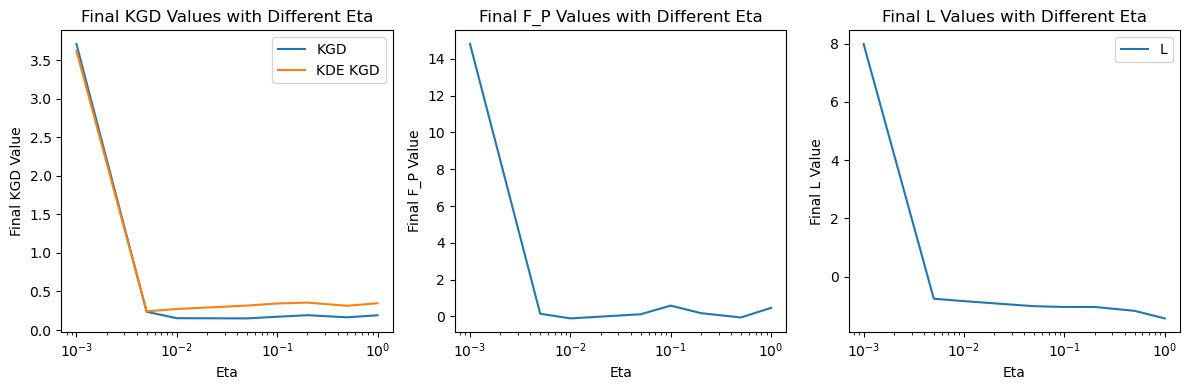

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  

# Plot the first figure (KGD_fin)
axes[0].plot(Eta, KGD_fin,label='KGD')
axes[0].plot(Eta, KDE_KGD_fin,label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()

# Plot the second figure (F_P_fin)
axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

# Plot the third figure (L_fin)
axes[2].plot(Eta, L_fin)
axes[2].set_xlabel('Eta')
axes[2].set_ylabel('Final L Value')
axes[2].set_xscale('log')
axes[2].set_title('Final L Values with Different Eta')
axes[2].legend(['L'])


plt.tight_layout()
plt.show()

<!-- In what follows we controll visually that the distribution converges to $\mathcal{N}(0,2 I_d)$. -->

# 3. MMD

### a) Q_1 is a Gaussian
- $\mathcal{L}(Q) = \frac{\gamma}{2} \textrm{MMD}(Q,Q_1)^2$
- $Q_1 = \mathcal{N}(\mu,\Sigma)$ where $\mu = (5,5)$, $\Sigma = I_d$
- Gaussian kernel in the MMD: $l(x,x') = \exp(-\frac{\|x-x'\|^2}{2 \sigma_l^2})$

In [27]:
c = jnp.array(1.0)
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y))) 

x2 = jnp.array([5,5])
def q_0(x):
    return jnp.exp(-jnp.dot(x,x)/(2*4)) / jnp.sqrt((2* 4  *jnp.pi)**d)

sigma_l = 1.0
l = lambda x,y : ker.k_IMQ(x,y,sigma_l) #Gram matrix for gaussian kernel

d = 2
Cov = np.diag(jnp.ones(d))
n1 = 70
mu = 5*np.ones(d)

key = random.PRNGKey(98)  
shape1 = (n1, d)
X1 = random.multivariate_normal(key,mu,Cov,n1)

gamma = 100
def L(X):
    _X = jax.lax.stop_gradient(X)
    return gamma/2 * (np.mean(l(X,_X)) - 2 * np.mean(l(X,X1)) + np.mean(l(X1,X1)))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)

MFLD = MeanFieldLangevinDynamics(q_0,L,k)

NameError: name 'v' is not defined

In [28]:
T = 500
n = 50
Eta = jnp.logspace(-3,1,10)
n_sim = 1
devise = jax.devices(device_name)[0]  

all_particles_fin = jax.device_put(jnp.zeros((len(Eta), n, d)), device)

for e, eta in enumerate(Eta):
    for sim in range(n_sim):
        key_init = random.PRNGKey(100 + sim)
        key = random.PRNGKey(200 + sim)
        shape = (n, d)
        X0 = random.normal(key_init, shape) + 5 * jnp.ones((n, d))
        X0 = jax.device_put(X0, device)
        all_particles = MFLD.run_particles(eta, T, X0,key)
    
    all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])


NameError: name 'device' is not defined

In [29]:
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
KDE_KGD_fin = jax.device_put(jnp.zeros(len(Eta)), device)
F_P_fin = jax.device_put(jnp.zeros(len(Eta)), device)
L_fin = jax.device_put(jnp.zeros(len(Eta)), device)

for e in range(len(Eta)):
    X = all_particles_fin[e] 
    KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
    KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X))
    F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X))
    L_fin = L_fin.at[e].set(L(X))

NameError: name 'device' is not defined

ValueError: x and y must have same first dimension, but have shapes (10,) and (15,)

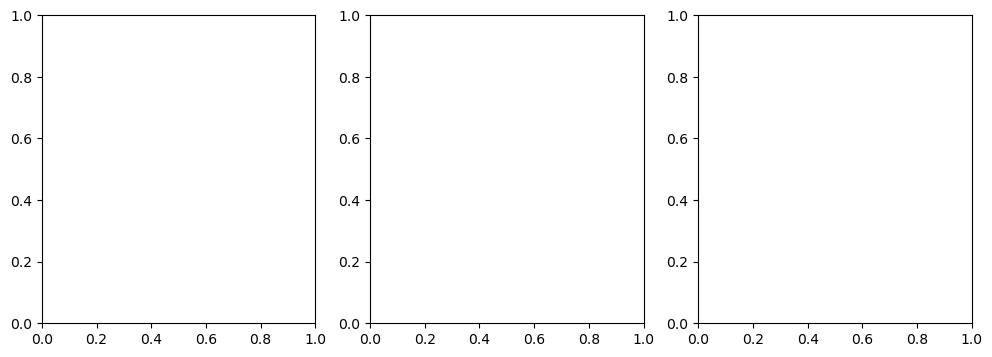

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  

axes[0].plot(Eta, KGD_fin, label='KGD')
axes[0].plot(Eta, KDE_KGD_fin, label='KDE KGD')
axes[0].set_xlabel('Eta')
axes[0].set_ylabel('Final KGD Value')
axes[0].set_xscale('log')
axes[0].set_title('Final KGD Values with Different Eta')
axes[0].legend()


axes[1].plot(Eta, F_P_fin)
axes[1].set_xlabel('Eta')
axes[1].set_ylabel('Final F_P Value')
axes[1].set_xscale('log')
axes[1].set_title('Final F_P Values with Different Eta')

axes[2].plot(Eta, L_fin)
axes[2].set_xlabel('Eta')      
axes[2].set_ylabel('Final L Value')
axes[2].set_xscale('log')
axes[2].set_title('Final L Values with Different Eta')
axes[2].legend(['L'])


plt.tight_layout()
plt.show()

Final particles postition : 

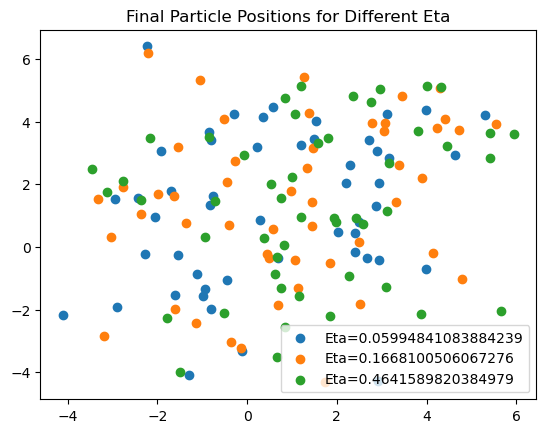

In [15]:
for e in range(4,len(Eta)-3):
    plt.scatter(all_particles_fin[e,:,0], all_particles_fin[e,:,1], label=f'Eta={Eta[e]}')
plt.title('Final Particle Positions for Different Eta')
plt.legend()

# 4 MFNN 
Here we consider random variables linked by the relation $y,z \in \mathbb{R}$ .$y = sin(z) + \varepsilon$ where $\varepsilon$ is a gaussian noise. Consider $N$ observations pf $(z,y)$, $(Z_1,Y_1),...,(Z_N,Y_N)$. $\mathcal{L} (Q) = \frac1N \sum_{i=1}^N (Y_i - \mathbb{E}_{X \sim Q} [\psi(X,Z)])^2$. The learning function $\psi$ is a two layer neural network with parameter $X$. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mfld import MeanFieldLangevinDynamics
import jax_kernels as ker
import functions as f
import time

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random
from jax.flatten_util import ravel_pytree
from jax import grad, random,vmap,tree_util

In [2]:
device_name = "cpu"

2 layer neural network :

Generation of the data

In [3]:

def generate_data(key, s, N, noise_std=0.1):
    key_z, key_noise = random.split(key)
    
    Z = random.uniform(key_z, (N, s),minval = 0,maxval=1.0)  # uniform distribution [-1,1]

    #explanation function
    def f(z):
        return jnp.sin(2 * jnp.pi * z[:,0])#, 0]) + 0.5 * Z[:, 1]**2 - jnp.exp(-Z[:, 2])

    Y_clean = f(Z)

    # noise
    noise = noise_std * random.normal(key_noise, shape=Y_clean.shape)
    Y= Y_clean + noise

    return Z, Y

N = 300
s=1 #input dimension 
key_data = random.PRNGKey(8)
Z,Y = generate_data(key_data,s, N, noise_std=0.1) # put more noise
#plt.plot(Z,Y,".")


$k$, $q_0$ and $\mathcal{L}$

In [4]:
kernel_name = "IMQ"
c = jnp.array(1.0)
b = 3.0
def k(x,y):
    return (c**2 + (x-y).dot(x-y))**(-b)
    #return jnp.dot(x,y)

def q_0(x):
    d = jax.lax.stop_gradient(len(x))
    return jnp.exp(-jnp.dot(x,x)/(2*4)) #/ jnp.sqrt((2 * jnp.pi)**d)


key = random.PRNGKey(0)
hidden_dim = 1
model = f.MLP(hidden_dims=[1], output_dim=1)
params = model.init(key, jnp.ones((s,)))  
flat_params, unravel_fn = ravel_pytree(params)
d = len(flat_params)  


def esp_forward(X, z):
    E = jnp.mean(jit(vmap(lambda x : model.apply(unravel_fn(x), z)))(X))
    return E
gamma = 100
def L(X):  
    n = len(X)
    Esp_forward = vmap(lambda z: esp_forward(X, z))(Z)  
    return gamma * jnp.mean((Esp_forward - Y) ** 2) 

k = jit(k)
q_0 = jit(q_0)
esp_forward = jit(esp_forward)
L = jit(L)  
 
MFLD = MeanFieldLangevinDynamics(q_0,L,k)    

In [5]:
# T = 10000
# n = 50

# Eta = jnp.logspace(-6,-2,15)
# key = random.PRNGKey(14)


# all_particles_fin = jnp.zeros((len(Eta), n, d))

# for e, eta in enumerate(Eta):
#     key_init = random.PRNGKey(200)
#     key = random.PRNGKey(3)
#     X_list = [model.init(random.fold_in(key_init, i),jnp.ones((s,))) for i in range(n)]
#     flat_X_list = [ravel_pytree(p)[0] for p in X_list]  
#     X0 = jnp.stack(flat_X_list)
#     all_particles = MFLD.run_particles(eta, T, X0,key)

#     all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])



In [6]:
# F_P = f.F_P(q_0, L)
# k_pq = f.GradientKernel(MFLD.S_PQ,k)
# KGD = f.KernelGradientDiscrepancy(k_pq)

# KGD_fin = jnp.zeros(len(Eta))
# KDE_KGD_fin =jnp.zeros(len(Eta))
# F_P_fin = jnp.zeros(len(Eta))
# L_fin = jnp.zeros(len(Eta))

# for e in range(len(Eta)):
#     X = all_particles_fin[e] 
#     KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
#     KDE_KGD_fin = KDE_KGD_fin.at[e].set(KGD.kde_KGD(X,num_samples = 300))
#     F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X,num_samples = 300))
#     L_fin = L_fin.at[e].set(L(X))


to do : plot the parameters

In [7]:
# fig, axes = plt.subplots(1, 3, figsize=(12, 4))  

# # Plot the first figure (KGD_fin)
# axes[0].plot(Eta[:-2], KGD_fin[:-2], label='KGD')
# #axes[0].plot(Eta, KDE_KGD_fin, label='KDE KGD')
# axes[0].set_xlabel('Eta')
# axes[0].set_ylabel('Final KGD Value')
# axes[0].set_xscale('log')
# axes[0].set_title('Final KGD Values with Different Eta')
# axes[0].legend()

# # Plot the second figure (F_P_fin)
# axes[1].plot(Eta, F_P_fin)
# axes[1].set_xlabel('Eta')
# axes[1].set_ylabel('Final F_P Value')
# axes[1].set_xscale('log')
# axes[1].set_title('Final F_P Values with Different Eta')

# axes[2].plot(Eta, 1/gamma * L_fin)
# axes[2].set_xlabel('Eta')
# axes[2].set_ylabel('Final L Value')
# axes[2].set_xscale('log')
# axes[2].set_title('Final L Values with Different Eta (Mean squared error)')

# plt.tight_layout()
# plt.show()

In [8]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Paramètres
T = 10000
n = 50
nb_runs = 10   # nombre de répétitions de l'expérience

Eta = jnp.logspace(-6, -2, 15)

F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

# Tableaux pour stocker tous les runs
KGD_all   = jnp.zeros((nb_runs, len(Eta)))
F_P_all   = jnp.zeros((nb_runs, len(Eta)))
L_all     = jnp.zeros((nb_runs, len(Eta)))

for r in range(nb_runs):
    print(f"Run {r+1}/{nb_runs}")

    all_particles_fin = jnp.zeros((len(Eta), n, d))

    for e, eta in enumerate(Eta):
        key_init = random.PRNGKey(200 + r)   # varier les seeds par run
        key = random.PRNGKey(3 + r)

        X_list = [model.init(random.fold_in(key_init, i), jnp.ones((s,))) for i in range(n)]
        flat_X_list = [ravel_pytree(p)[0] for p in X_list]
        X0 = jnp.stack(flat_X_list)

        all_particles = MFLD.run_particles(eta, T, X0, key)
        all_particles_fin = all_particles_fin.at[e].set(all_particles[-1])

     # Evaulation of the metrics
    KGD_fin = jnp.zeros(len(Eta))
    F_P_fin = jnp.zeros(len(Eta))
    L_fin   = jnp.zeros(len(Eta))
    KGD_KDE_fin = jnp.zeros(len(Eta))

    for e in range(len(Eta)):
        X = all_particles_fin[e]
        KGD_fin = KGD_fin.at[e].set(KGD.evaluate(X))
        F_P_fin = F_P_fin.at[e].set(F_P.evaluate(X, num_samples=300))
        L_fin   = L_fin.at[e].set(L(X))
        KGD_KDE_fin = KGD_KDE_fin.at[e].set(KGD.kde_KGD(X, num_samples=300))

    
    KGD_all = KGD_all.at[r].set(KGD_fin)
    F_P_all = F_P_all.at[r].set(F_P_fin)
    L_all   = L_all.at[r].set(L_fin)
    KGD_KDE_all = KGD_all.at[r].set(KGD_KDE_fin)

# quantiles
def summary_stats(arr):
    mean = arr.mean(axis=0)
    q10 = jnp.quantile(arr, 0.1, axis=0)
    q90 = jnp.quantile(arr, 0.9, axis=0)
    return mean, q10, q90

KGD_mean, KGD_q10, KGD_q90 = summary_stats(KGD_all)
F_P_mean, F_P_q10, F_P_q90 = summary_stats(F_P_all)
L_mean, L_q10, L_q90       = summary_stats(L_all)
KGD_KDE_mean, KGD_KDE_q10, KGD_KDE_q90 = summary_stats(KGD_KDE_all)



Run 1/10
Run 2/10
Run 3/10
Run 4/10
Run 5/10
Run 6/10
Run 7/10
Run 8/10
Run 9/10
Run 10/10


In [9]:
import csv

# Recalculer les bonnes statistiques
KGD_mean, KGD_q10, KGD_q90 = summary_stats(KGD_all)
F_P_mean, F_P_q10, F_P_q90 = summary_stats(F_P_all)
L_mean, L_q10, L_q90 = summary_stats(L_all)
KGD_KDE_mean, KGD_KDE_q10, KGD_KDE_q90 = summary_stats(KGD_KDE_all)

# Sauvegarder correctement
with open("summary_stats.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Variable", "Mean", "Q10", "Q90"])
    writer.writerow(["KGD", KGD_mean, KGD_q10, KGD_q90])
    writer.writerow(["F_P", F_P_mean, F_P_q10, F_P_q90])
    writer.writerow(["L", L_mean, L_q10, L_q90])
    writer.writerow(["KGD_KDE", KGD_KDE_mean, KGD_KDE_q10, KGD_KDE_q90])

In [21]:
import pandas as pd

df = pd.read_csv("summary_stats.csv")

import numpy as np

def str_to_float_array(s):
    return np.fromstring(s.strip('[]'), sep=' ')

# Accès propre avec .iloc[0]
KGD_mean     = str_to_float_array(df.loc[df['Variable'] == 'KGD', 'Mean'].iloc[0])
KGD_q10      = str_to_float_array(df.loc[df['Variable'] == 'KGD', 'Q10'].iloc[0])
KGD_q90      = str_to_float_array(df.loc[df['Variable'] == 'KGD', 'Q90'].iloc[0])

# F_P
F_P_mean     = str_to_float_array(df.loc[df['Variable'] == 'F_P', 'Mean'].iloc[0])
F_P_q10      = str_to_float_array(df.loc[df['Variable'] == 'F_P', 'Q10'].iloc[0])
F_P_q90      = str_to_float_array(df.loc[df['Variable'] == 'F_P', 'Q90'].iloc[0])

# L
L_mean       = str_to_float_array(df.loc[df['Variable'] == 'L', 'Mean'].iloc[0])
L_q10        = str_to_float_array(df.loc[df['Variable'] == 'L', 'Q10'].iloc[0])
L_q90        = str_to_float_array(df.loc[df['Variable'] == 'L', 'Q90'].iloc[0])

# KGD_KDE
KGD_KDE_mean = str_to_float_array(df.loc[df['Variable'] == 'KGD_KDE', 'Mean'].iloc[0])
KGD_KDE_q10  = str_to_float_array(df.loc[df['Variable'] == 'KGD_KDE', 'Q10'].iloc[0])
KGD_KDE_q90  = str_to_float_array(df.loc[df['Variable'] == 'KGD_KDE', 'Q90'].iloc[0])

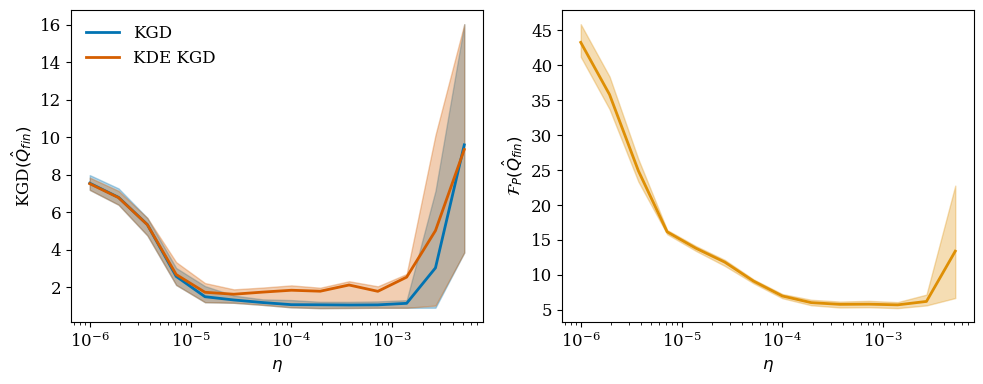

In [23]:
import seaborn as sns
colors = sns.color_palette("colorblind")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# KGD
axes[0].plot(Eta, KGD_mean, label="KGD", color=colors[0], linewidth=2)
axes[0].fill_between(Eta, KGD_q10, KGD_q90, alpha=0.3, color=colors[0])
axes[0].plot(Eta, KGD_KDE_mean, label="KDE KGD", color=colors[3], linewidth=2)
axes[0].fill_between(Eta, KGD_KDE_q10, KGD_KDE_q90, alpha=0.3, color=colors[3])
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\eta$")
axes[0].set_ylabel(r"KGD$(\hat{Q}_{fin})$")
#axes[0].set_title(r"KGD Final vs. $\eta$")
axes[0].legend(frameon=False)

# F_P
axes[1].plot(Eta, F_P_mean, label="F_P (mean)", color=colors[1], linewidth=2)
axes[1].fill_between(Eta, F_P_q10, F_P_q90, alpha=0.3, color=colors[1])
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\eta$")
axes[1].set_ylabel(r"$\mathcal{F}_P(\hat{Q}_{fin})$")
#axes[1].set_title(r"$\mathcal{F}_P$ Final vs. $\eta$")

# # L
# axes[2].plot(Eta, (1/gamma) * L_mean, label="L (mean)", color=colors[2], linewidth=2)
# axes[2].fill_between(Eta, (1/gamma) * L_q10, (1/gamma) * L_q90, alpha=0.3, color=colors[2])
# axes[2].set_xscale("log")
# axes[2].set_xlabel(r"Learning Rate ($\eta$)")
# axes[2].set_ylabel("Final MSE")
# axes[2].set_title("MSE Final vs. Eta")

plt.tight_layout()
plt.savefig("final_metrics_plot.pdf", bbox_inches='tight')

In [27]:
# Check if the best stepsize is the same for KGD and F_P
e_min_KGD = jnp.argmin(KGD_mean[:-1])
e_min_F_P = jnp.argmin(F_P_mean[:-1])
print(f"Best Eta for KGD: {Eta[e_min_KGD]:.4f}")
print(f"Best Eta for F_P: {Eta[e_min_F_P]:.4f}")


Best Eta for KGD: 0.0004
Best Eta for F_P: 0.0014


Plot of the predictions

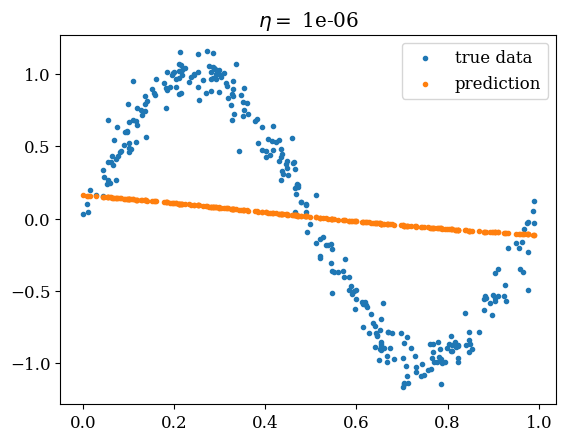

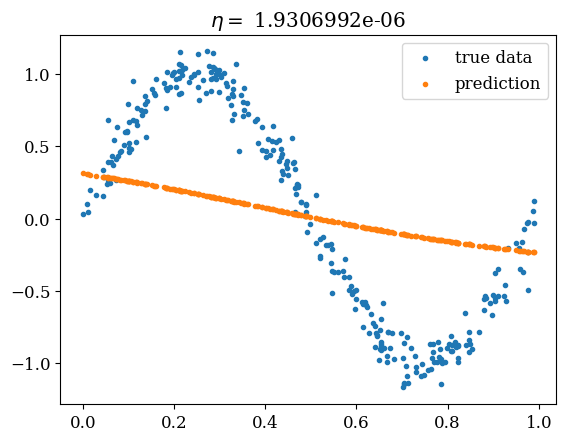

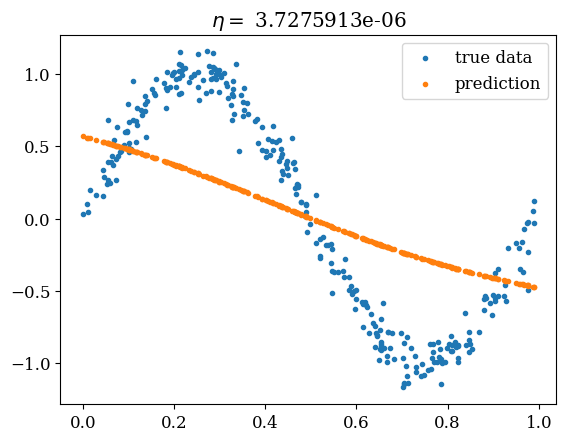

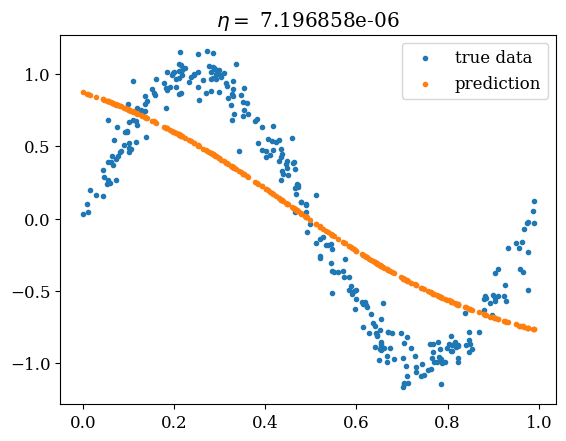

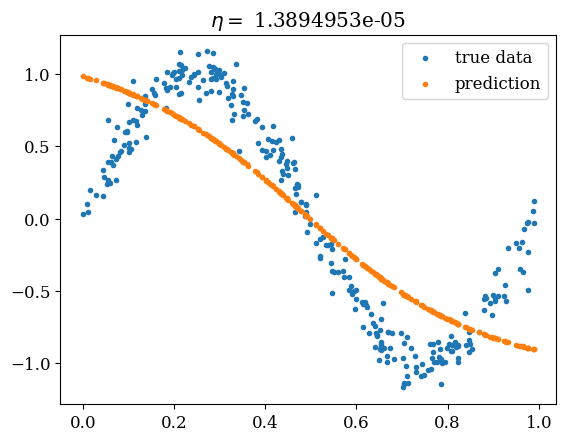

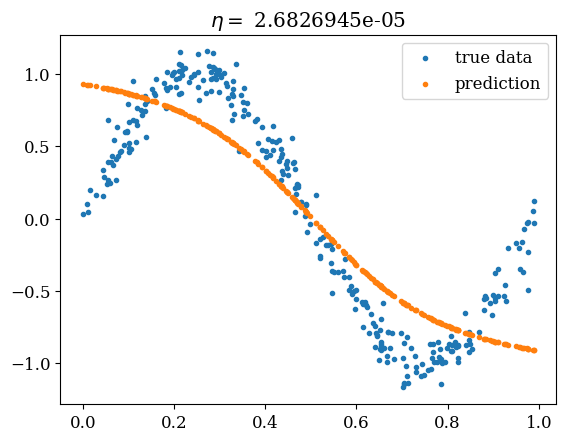

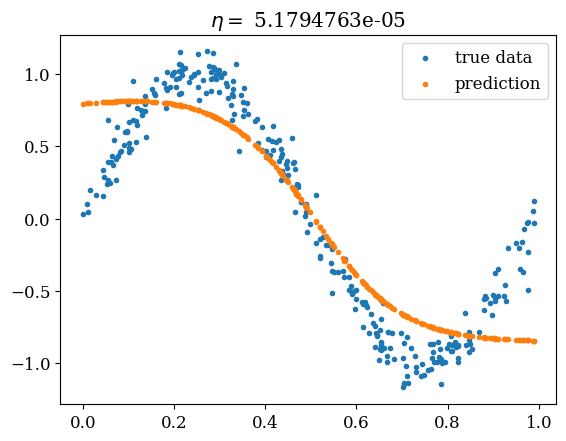

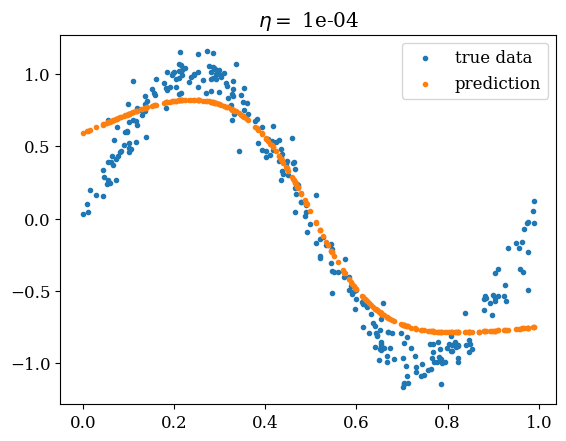

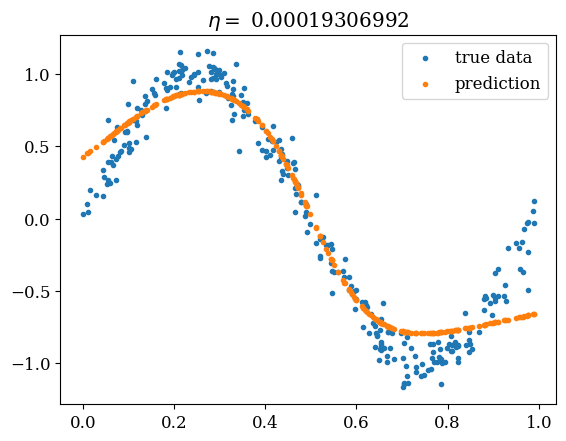

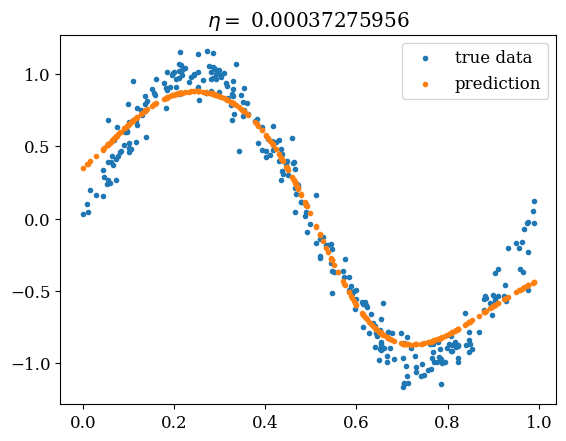

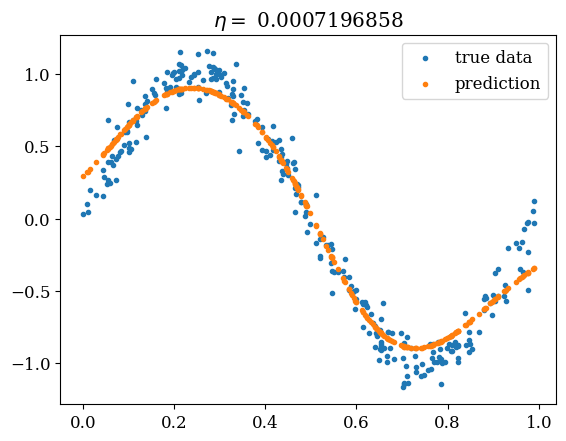

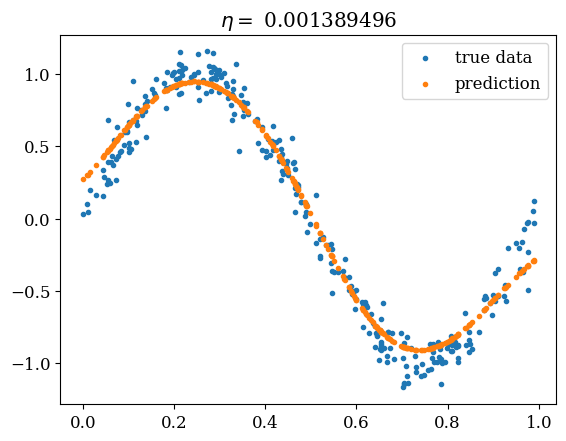

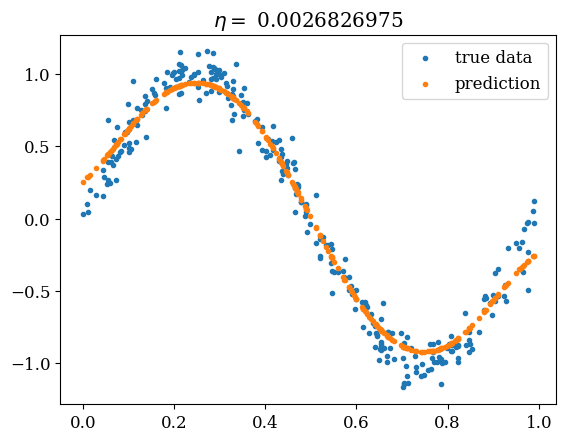

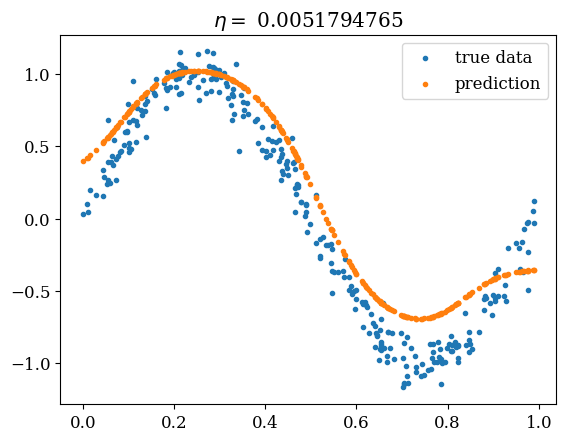

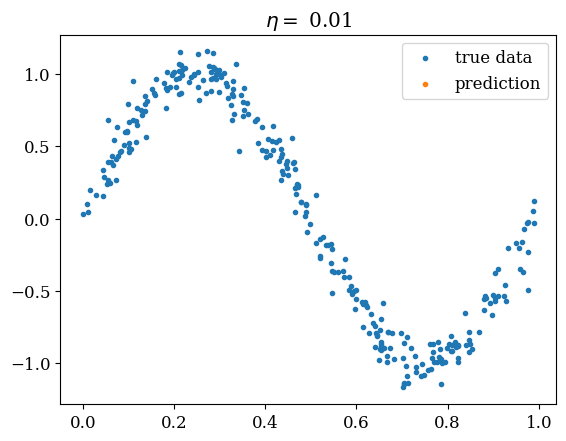

In [13]:
for e in range(len(Eta)):
    plt.figure()
    plt.scatter(Z,Y,label = "true data",marker = ".")
    X_fin = all_particles_fin[e]
    Y_hat = vmap(lambda z : esp_forward(X_fin, z))(Z)
    plt.scatter(Z,Y_hat,label = "prediction",marker = ".")
    plt.legend()
    plt.title(r"$\eta = $ " + str(Eta[e]))


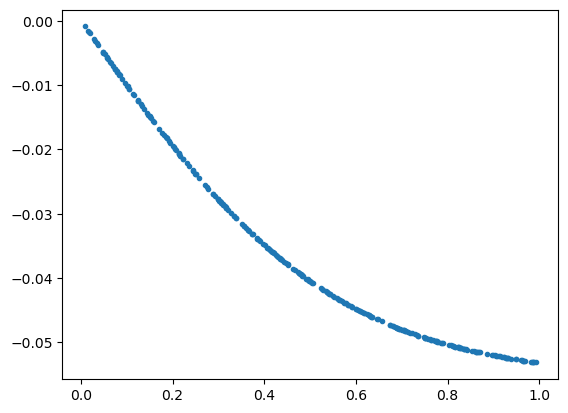

In [20]:
Y_hat = vmap(lambda z : esp_forward(X0, z))(Z)
plt.scatter(Z,Y_hat,label = "prediction",marker = ".")